<a href="https://colab.research.google.com/github/ostapenkooleksandr-hash/ida-practice-3d/blob/main/practice/1/1-homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lesson 1 — Homework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djnzx/ida-practice-3d/blob/main/practice/1/1-homework.ipynb)

**Estimated time: 3-4 hours.**

## How to work through this

Each task gives you a function signature and a docstring stating exactly
what the function must return. Replace the `raise NotImplementedError` with
your implementation. The cell immediately after each task contains
`assert` statements that check your work.

**A failing assert is information, not a grade.** It tells you that the
behaviour does not yet match the contract. Read the assertion message, fix
the function, re-run the cell. There is no penalty for running a cell
twenty times.

The written questions are marked. They are the part of this homework that
carries the learning objective: each one asks you to *run something both
ways and explain the difference*, not to recall a fact. Answers of one
sentence will not be enough; answers of one paragraph, referring to numbers
you actually produced, will.

Every function you need has been demonstrated in `1-practice.ipynb`. Each
task names the section — `see Practice 1 §3.6` — where the relevant material
is. You should not need any other documentation, and you should not need to
search the internet. If you find yourself wanting to, the reference is
probably in the practice notebook and worth finding.

## Before you submit

**Runtime → Restart and run all must complete without error**, with every
assert passing. A notebook that only works because you ran the cells in an
unusual order is not reproducible, and reproducibility is the subject of
§4.1 of the practice notebook.

Then **File → Download → Download .ipynb**, rename the file to
`1-homework-results.ipynb`, and commit it to your fork under
`practice/1/`. Keep the outputs in the file; do not clear them.
The full procedure is in `practice/README.md` §8.

## 1. Setup

Run this first. It is the same configuration cell as the practice notebook.

In [45]:
import sys

import numpy as np
import matplotlib.pyplot as plt

SEED = 20250919
rng = np.random.default_rng(SEED)

plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["font.size"] = 11
plt.rcParams["lines.linewidth"] = 2.0

print("python", sys.version.split()[0], "| numpy", np.__version__)

python 3.13.15 | numpy 2.1.3


## 2. Task 1 — Describe an array

Mechanical. Return the five attributes that describe an array's layout.

*see Practice 1 §3.2*

In [46]:
def describe_array(arr):
    """Return a dict describing the memory layout of `arr`.

    Keys, exactly these five:
        'dtype'    the element type, as a string (use str(...) on the dtype)
        'shape'    the shape, as a tuple
        'ndim'     the number of dimensions, as an int
        'size'     the total number of elements, as an int
        'nbytes'   the total number of bytes occupied by the data, as an int

    No allocation and no copying: read the attributes off `arr`.
    """
    return {
        'dtype': str(arr.dtype),
        'shape': arr.shape,
        'ndim': arr.ndim,
        'size': arr.size,
        'nbytes': arr.nbytes
    }
    raise NotImplementedError("Task 1")

In [47]:
_result = describe_array(np.zeros((3, 4), dtype=np.float64))
assert set(_result) == {"dtype", "shape", "ndim", "size", "nbytes"}, \
    f"expected exactly those five keys, got {sorted(_result)}"
assert _result["shape"] == (3, 4), f"shape wrong: {_result['shape']}"
assert _result["ndim"] == 2, f"ndim wrong: {_result['ndim']}"
assert _result["size"] == 12, f"size wrong: {_result['size']}"
assert _result["nbytes"] == 96, f"nbytes wrong: {_result['nbytes']} (12 elements x 8 bytes)"
assert "float64" in _result["dtype"], f"dtype wrong: {_result['dtype']}"

_int_result = describe_array(np.arange(10, dtype=np.int32))
assert _int_result["nbytes"] == 40, "an int32 array of 10 elements occupies 40 bytes"
assert _int_result["ndim"] == 1

print("Task 1 passed.")

Task 1 passed.


## 3. Task 2 — A view bug, and the fix

The function below is supposed to return a copy of the middle of an array
with its values clipped to zero, leaving the caller's array untouched. It
does not. Find the defect and repair it.

Do not change the signature and do not change what the function returns —
only make it stop modifying its argument.

*see Practice 1 §3.6*

In [55]:
def zero_the_middle(arr, start, stop):
    """Return a NEW array holding arr[start:stop] with every value set to 0.

    `arr` must not be modified. The returned array must have length
    stop - start and must not share memory with `arr`.

    The body below is the broken version. Fix it.
    """
    middle = arr[start:stop].copy()
    middle[:] = 0
    return middle

In [56]:
_original = np.arange(10)
_untouched = np.arange(10)
_returned = zero_the_middle(_original, 3, 6)

assert np.array_equal(_original, _untouched), \
    f"the argument was modified: {_original} should still be {_untouched}"
assert _returned.shape == (3,), f"wrong length: {_returned.shape}"
assert np.all(_returned == 0), f"values not zeroed: {_returned}"
assert not np.shares_memory(_returned, _original), \
    "the result still shares memory with the argument"

print("Task 2 passed.")

Task 2 passed.


## 4. Task 3 — Standardise the columns of a matrix

Applied. Subtract each column's mean and divide by each column's standard
deviation, using broadcasting rather than a loop over columns.

This is what `StandardScaler` does, and Practice 2 §9 will use the
scikit-learn object. Writing it once by hand is the point.

*see Practice 1 §3.7 and §3.8*

In [60]:
def standardise_columns(matrix):
    """Return `matrix` with every column centred and scaled to unit variance.

    For each column j:  out[:, j] = (matrix[:, j] - mean_j) / sd_j

    Use the population standard deviation (NumPy's default, ddof=0).
    The result has the same shape as `matrix`. Do not modify `matrix`.
    Use broadcasting; do not write a `for` loop over the columns.
    """
    means = matrix.mean(axis=0)
    stds = matrix.std(axis=0)
    return (matrix - means) / stds
    raise NotImplementedError("Task 3")

In [62]:
_data = np.array([[1.0, 100.0],
                  [2.0, 200.0],
                  [3.0, 300.0],
                  [4.0, 400.0]])
_before = _data.copy()
_scaled = standardise_columns(_data)

assert _scaled.shape == _data.shape, f"shape changed: {_scaled.shape}"
assert np.array_equal(_data, _before), "the input matrix was modified"
assert np.allclose(_scaled.mean(axis=0), 0.0), \
    f"columns not centred, means are {_scaled.mean(axis=0)}"
assert np.allclose(_scaled.std(axis=0), 1.0), \
    f"columns not unit variance, sds are {_scaled.std(axis=0)}"
# The two columns are the same numbers on different scales, so after
# standardising they must be identical.
assert np.allclose(_scaled[:, 0], _scaled[:, 1]), \
    "a linear rescaling of a column should standardise to the same values"

_wide = rng.normal(5.0, 3.0, size=(200, 7))
assert np.allclose(standardise_columns(_wide).mean(axis=0), 0.0, atol=1e-12)
assert np.allclose(standardise_columns(_wide).std(axis=0), 1.0)

print("Task 3 passed.")

Task 3 passed.


## 5. Task 4 — Reductions along an axis

Mechanical, but the axis argument is the thing being tested. Read the
docstring carefully: two of these collapse rows and two collapse columns.

*see Practice 1 §3.8*

In [66]:
def axis_summary(matrix):
    """Return a dict of four reductions of a 2-D array.

    Keys and contents:
        'per_column_mean'  one value per COLUMN, shape (n_columns,)
        'per_row_sum'      one value per ROW,    shape (n_rows,)
        'per_row_max'      one value per ROW,    shape (n_rows,)
        'grand_total'      the sum of every element, a scalar float

    Return NumPy arrays for the first three and a Python/NumPy float for
    the last.
    """
    return {
        'per_column_mean': matrix.mean(axis=0),
        'per_row_sum': matrix.sum(axis=1),
        'per_row_max': matrix.max(axis=1),
        'grand_total': float(matrix.sum())
        }
    raise NotImplementedError("Task 4")

In [67]:
_grid = np.array([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])
_summary = axis_summary(_grid)

assert _summary["per_column_mean"].shape == (3,), \
    f"per_column_mean should have one value per column: {_summary['per_column_mean'].shape}"
assert np.allclose(_summary["per_column_mean"], [2.5, 3.5, 4.5])
assert _summary["per_row_sum"].shape == (2,), \
    f"per_row_sum should have one value per row: {_summary['per_row_sum'].shape}"
assert np.allclose(_summary["per_row_sum"], [6.0, 15.0])
assert np.allclose(_summary["per_row_max"], [3.0, 6.0])
assert np.isclose(_summary["grand_total"], 21.0)

# A non-square array catches an axis swapped by accident.
_tall = rng.normal(size=(50, 4))
_tall_summary = axis_summary(_tall)
assert _tall_summary["per_column_mean"].shape == (4,)
assert _tall_summary["per_row_sum"].shape == (50,)

print("Task 4 passed.")

Task 4 passed.


### Question 1 — the axis argument

Take the `(50, 4)` array `_tall` from the cell above. Compute `_tall.sum()`,
`_tall.sum(axis=0)` and `_tall.sum(axis=1)`, and print the shape of each.

Explain, in your own words, **why `axis=0` produces four numbers and not
fifty**, given that the array has fifty rows. Then state which of the three
you would use to answer the question "what is the average value of each
feature across all samples", and why.

In [75]:
import numpy as np
sum_all = _tall.sum()
sum_axis0 = _tall.sum(axis=0)
sum_axis1 = _tall.sum(axis=1)
print(f"Shape of _tall.sum(): {np.shape(sum_all)}")
print(f"Shape of _tall.sum(axis=0): {sum_axis0.shape}")
print(f"Shape of _tall.sum(axis=1): {sum_axis1.shape}")

Shape of _tall.sum(): ()
Shape of _tall.sum(axis=0): (4,)
Shape of _tall.sum(axis=1): (50,)


**Your answer:**

_(replace this line)_

Чому axis=0 дає чотири числа, а не п'ятдесят?
Аргумент axis вказує NumPy, який саме вимір масиву має "згорнутися" (або колапсувати) під час операції. У двовимірному масиві з формою (50, 4) axis=0 відповідає за рядки (перший вимір). Коли ми викликаємо sum(axis=0), операція рухається згори донизу вздовж колонок. Вона бере всі 50 елементів у першій колонці і стискає їх в одну суму. Потім робить те саме для другої, третьої та четвертої колонок. Оскільки рядки згорнулися, на виході залишається рівно стільки чисел, скільки було колонок — тобто 4.

Що обрати для "середнього значення кожної ознаки серед усіх зразків"?
Я б використав _tall.mean(axis=0).
У машинному навчанні та аналізі даних стандартною практикою є те, що рядки — це зразки (samples), а колонки — це ознаки (features). Оскільки в нашому масиві 50 зразків і 4 ознаки, нам потрібно знайти середнє значення для кожної ознаки окремо. Використовуючи axis=0, ми згортаємо всі 50 зразків, залишаючи 4 середні значення — по одному для кожної з 4 ознак.


## 6. Task 5 — Outliers by the k-sigma rule

Applied. Generalise the practice notebook's 3σ filter to an arbitrary threshold.

*see Practice 1 §3.9 and §4.7*

In [78]:
def sigma_outliers(sample, k=3.0):
    """Flag the values of `sample` that lie more than k standard deviations
    from the sample mean.

    Use the mean and standard deviation OF THE SAMPLE itself, not assumed
    values, and NumPy's default ddof=0 for the standard deviation.

    Return a tuple (mask, values):
        mask    a boolean array, the same shape as `sample`, True where the
                value is an outlier
        values  the outlying values themselves, in their original order

    Build the mask with a vectorised comparison; do not loop.
    """
    mean_val = np.mean(sample)
    std_val = np.std(sample)
    mask = np.abs(sample - mean_val) > (k * std_val)
    values = sample[mask]

    return mask, values
    raise NotImplementedError("Task 5")

In [79]:
_plain = np.array([1.0, 2.0, 3.0, 2.0, 1.0, 50.0])
_mask, _values = sigma_outliers(_plain, k=2.0)

assert _mask.dtype == bool, f"mask must be boolean, got {_mask.dtype}"
assert _mask.shape == _plain.shape, f"mask shape {_mask.shape} != sample shape {_plain.shape}"
assert _mask.sum() == 1, f"expected exactly one outlier at k=2, found {_mask.sum()}"
assert np.allclose(_values, [50.0]), f"wrong value flagged: {_values}"

# On a clean normal sample the 3-sigma rule should flag very few points.
_normal = rng.normal(0.0, 1.0, 10_000)
_normal_mask, _ = sigma_outliers(_normal, k=3.0)
_rate = _normal_mask.mean()
assert 0.0 < _rate < 0.01, \
    f"flag rate {_rate:.4f} is implausible for 3 sigma on normal data (expect ~0.0027)"

# A larger threshold can never flag more points than a smaller one.
assert sigma_outliers(_normal, k=4.0)[0].sum() <= _normal_mask.sum()

print(f"Task 5 passed. 3-sigma flag rate on 10,000 normal draws: {_rate:.4%}")

Task 5 passed. 3-sigma flag rate on 10,000 normal draws: 0.3000%


### Question 2 — the threshold is a choice

Using the 10 000-point normal sample `_normal`, run `sigma_outliers` at
`k = 1, 2, 3, 4, 5` and print the number of points flagged at each.

Then answer: the theoretical fractions outside k standard deviations of a
normal distribution are about 32 %, 4.6 %, 0.27 %, 0.0063 % and 0.000057 %.
Compare your counts with those. **At which k does the sample stop having
enough data to estimate the rate at all**, and what does that imply about
using a very large k to define an outlier?

Finally: none of the points in `_normal` is an error — they all came from
the same generator. Describe one concrete situation in which you *would* be
justified in deleting a flagged point, and say what evidence would justify
it.

In [98]:
import numpy as np
print(f"Total points: {len(_normal)}")
for k in [1, 2, 3, 4, 5]:
    mask, vals = sigma_outliers(_normal, k=k)
    count = len(vals)
    emp_rate = count / len(_normal)
    print(f"k = {k:1d} | flagged: {count:4d} | empirical rate: {emp_rate:8.5%}")

Total points: 10000
k = 1 | flagged: 3160 | empirical rate: 31.60000%
k = 2 | flagged:  457 | empirical rate: 4.57000%
k = 3 | flagged:   30 | empirical rate: 0.30000%
k = 4 | flagged:    2 | empirical rate: 0.02000%
k = 5 | flagged:    0 | empirical rate: 0.00000%


**Your answer:**

На якому $k$ бракує даних і що це означає?Поріг недостатності: На $k = 4$ та $k = 5$ вибірка обсягом 10 000 точок перестає бути придатною для оцінки ставки. Очікувана кількість подій падає нижче одиниці ($0.63$ для $k=4$ та $0.0057$ для $k=5$). За законами статистики пуассонівського потоку/біноміального розподілу, коли $N \cdot p < 1$, емпірична частота майже завжди дорівнює $0$, що дає нульову оцінку ймовірності замість реального мікроскопічного хвоста.Імпликація для великого $k$: Використання величезного $k$ (наприклад, $k \ge 4$ на помірних датасетах) для визначення викидів через правила сигм є статистично дегенеративним. Вони нічого не знаходять у нормальному розподілі не тому, що дані «ідеальні», а тому що роздільна здатність вибірки надто мала для такого хвоста. А якщо дані реально мають важкі хвости (heavy-tailed), то емпіричне стандартне відхилення $\sigma$ саме по собі спотворюється викидами, роблячи будь-який вибір $k$ ненадійним.

Коли виправдано видалити позначену точку?Конкретна ситуація: Дані моніторингу температури процесора в сервері, де один із семплів показує 1023.0 °C (або 0.0 °C / максимальне значення 16-бітного реєстра 65535), тоді як сусідні по часу точки тримаються в діапазоні 45–55 °C.Докази, що виправдовують видалення:Апаратний/логічний метадані-лог: Наявність у системному лозі апаратного прапорця збою читання шини (I/O timeout / CRC error / ADC saturation flag) в той самий таймстемп.Фізичний ліміт градієнта (rate-of-change): Зміна значення між сусідніми мілісекундами виходить за межі фізичної теплоємності та теплопровідності кремнію ($\Delta T / \Delta t \gg$ фізичний максимум).

## 7. Task 6 — A NaN-aware mean, written by hand

Mechanical. Do not call `np.nanmean`; the point is to build it from the
masking tools.

*see Practice 1 §3.9 and §3.10*

In [91]:
def mean_ignoring_nan(sample):
    """Return the mean of the non-missing values of `sample`.

    Equivalent to np.nanmean, but you must implement it with np.isnan and
    boolean masking rather than calling any nan-aware NumPy reduction.

    If every value is missing, return np.nan.
    """
    valid_mask = ~np.isnan(sample)

    if not np.any(valid_mask):
        return np.nan

    return float(np.mean(sample[valid_mask]))
    raise NotImplementedError("Task 6")

In [92]:
assert np.isclose(mean_ignoring_nan(np.array([1.0, 2.0, np.nan, 4.0])), 7.0 / 3.0)
assert np.isclose(mean_ignoring_nan(np.array([5.0, 5.0, 5.0])), 5.0)
assert np.isnan(mean_ignoring_nan(np.array([np.nan, np.nan]))), \
    "an all-missing sample has no mean; return np.nan"

_with_gaps = rng.normal(0.0, 1.0, 1000)
_with_gaps[rng.choice(1000, size=100, replace=False)] = np.nan
assert np.isclose(mean_ignoring_nan(_with_gaps), np.nanmean(_with_gaps)), \
    "your result should agree with np.nanmean"
assert np.isnan(_with_gaps.mean()), \
    "sanity check: the plain mean of an array containing NaN is NaN"

print("Task 6 passed.")

Task 6 passed.


## 8. Task 7 — How well does a sample know its own distribution

Applied. Draw samples of increasing size from a known normal distribution
and measure how far the estimated parameters fall from the true ones.

*see Practice 1 §4.1 and §4.6*

In [95]:
def recover_parameters(true_mu, true_sigma, sizes, generator):
    """Estimate mu and sigma from samples of several sizes.

    For each n in `sizes`, draw n values from normal(true_mu, true_sigma)
    using `generator`, and record the sample mean and the UNBIASED sample
    standard deviation (ddof=1).

    Draw the samples in the order the sizes are given, taking every sample
    from the same `generator` object, so that the result is reproducible
    for a given seed.

    Return a dict with three keys, each a NumPy array of len(sizes):
        'n'          the sample sizes, as given
        'mu_hat'     the estimated means
        'sigma_hat'  the estimated standard deviations
    """
    n_arr = np.array(sizes)
    mu_hat = np.empty(len(sizes), dtype=float)
    sigma_hat = np.empty(len(sizes), dtype=float)

    for i, n in enumerate(sizes):
        sample = generator.normal(loc=true_mu, scale=true_sigma, size=n)
        mu_hat[i] = np.mean(sample)
        sigma_hat[i] = np.std(sample, ddof=1)

    return {
        'n': n_arr,
        'mu_hat': mu_hat,
        'sigma_hat': sigma_hat
    }
    raise NotImplementedError("Task 7")

In [96]:
_sizes = [10, 100, 1_000, 10_000, 100_000]
_recovered = recover_parameters(2.0, 5.0, _sizes, np.random.default_rng(0))

assert set(_recovered) == {"n", "mu_hat", "sigma_hat"}
assert len(_recovered["mu_hat"]) == len(_sizes)
assert np.array_equal(_recovered["n"], np.array(_sizes))

# Reproducible: the same seed must give the same estimates.
_again = recover_parameters(2.0, 5.0, _sizes, np.random.default_rng(0))
assert np.allclose(_recovered["mu_hat"], _again["mu_hat"]), \
    "same seed gave different answers; are you drawing from the generator you were passed?"

# The largest sample must land close to the truth.
assert abs(_recovered["mu_hat"][-1] - 2.0) < 0.1, \
    f"mu estimate from 100,000 draws is {_recovered['mu_hat'][-1]:.4f}, expected near 2.0"
assert abs(_recovered["sigma_hat"][-1] - 5.0) < 0.1, \
    f"sigma estimate from 100,000 draws is {_recovered['sigma_hat'][-1]:.4f}, expected near 5.0"

# and the error should shrink as n grows
_err_small = abs(_recovered["mu_hat"][0] - 2.0)
_err_large = abs(_recovered["mu_hat"][-1] - 2.0)
assert _err_large < _err_small, "the estimate should improve with more data"

for n, mu, sd in zip(_recovered["n"], _recovered["mu_hat"], _recovered["sigma_hat"]):
    print(f"n = {n:7,}   mu_hat = {mu:8.4f}   sigma_hat = {sd:8.4f}")
print("\nTask 7 passed.")

n =      10   mu_hat =   2.4234   sigma_hat =   3.9067
n =     100   mu_hat =   2.2577   sigma_hat =   4.9827
n =   1,000   mu_hat =   1.7686   sigma_hat =   4.9318
n =  10,000   mu_hat =   2.0434   sigma_hat =   5.0002
n = 100,000   mu_hat =   1.9896   sigma_hat =   5.0035

Task 7 passed.


### Question 3 — the seed and the sample size

Two experiments.

**(a)** Call `recover_parameters(2.0, 5.0, [100], ...)` with five *different*
seeds. Record the five estimates of mu. How much do they vary?

**(b)** Call it with a single fixed seed but sizes `[100, 10_000]`. How far
is each estimate from 2.0?

Now explain the distinction these two experiments draw out. **The seed
controls one thing and the sample size controls a different thing — name
both.** In particular: does a larger seed give a better answer? Does
re-running with a new seed tell you anything you did not know? And if your
estimate at n = 100 is off by 0.4, is that a bug?

Use the error at n = 100 and at n = 10 000 to estimate how the error scales
with n, and compare it with the square-root rule from Practice 1 §4.6.

In [97]:
import numpy as np

true_mu, true_sigma = 2.0, 5.0

# (a) 5 різних сидів для n = 100
mu_seeds = []
for seed_val in range(5):
    gen_a = np.random.default_rng(seed_val)
    res_a = recover_parameters(true_mu, true_sigma, [100], gen_a)
    mu_seeds.append(res_a['mu_hat'][0])

mu_seeds = np.array(mu_seeds)
print("Експеримент (a) - μ_hat для 5 сидів:", mu_seeds)
print("Варіація (стандартне відхилення між сидами):", np.std(mu_seeds))

# (b) Один фіксований сид для n = [100, 10_000]
gen_b = np.random.default_rng(42)
res_b = recover_parameters(true_mu, true_sigma, [100, 10_000], gen_b)
errors_b = np.abs(res_b['mu_hat'] - true_mu)
print("Експеримент (b) - похибки |μ_hat - true_mu|:", errors_b)

Експеримент (a) - μ_hat для 5 сидів: [2.40548347 1.63193939 1.957903   1.69114663 1.68348663]
Варіація (стандартне відхилення між сидами): 0.28908075921823073
Експеримент (b) - похибки |μ_hat - true_mu|: [0.25134806 0.05261644]


**Your answer:**
Чи дає «більший сид» кращий результат? Ні. Сид — це просто ідентифікатор/початковий індекс стану генератора (наприклад, seed=42 не «кращий» чи «більший» за seed=1, це просто інша точка стабільного потоку хаосу).Чи дає перезапуск із новим сидом щось нове?Один додатковий перезапуск показує іншу реалізацію випадковості (реалізацію Monte Carlo). Са по собі заміна сиду не покращує модель, але серія перезапусків (ансамбль/бутстреп) допомагає оцінити емпіричну дисперсію оцінки.Якщо оцінка при $n = 100$ відрізняється на $0.4$, чи це баг?Ні, це не баг. Теоретична стандартна похибка середнього становить $\text{SE} = \frac{\sigma}{\sqrt{n}} = \frac{5.0}{\sqrt{100}} = \frac{5.0}{10} = 0.5$. Відхилення на $0.4$ менше за одне стандартне відхилення ($0.4 < 0.5$, тобто $0.8\times \text{SE}$), що трапляється дуже часто (приблизно в 40% випадків нормальної вибірки).

Масштабування похибки та правило квадратного кореняТеоретичне очікування:Стандартна похибка зменшується обернено пропорційно $\sqrt{n}$. При переході від $n=100$ до $n=10\,000$ зміна розміру вибірки становить фактор $\frac{10\,000}{100} = 100$. Оскільки корінь з 100 дорівнює 10, теоретична похибка при $n=10\,000$ має бути приблизно у 10 разів меншою, ніж при $n=100$.Порівняння з емпірикою:Якщо ваша емпірична похибка при $n=100$ була ~0.4, то при $n=10\,000$ вона має складати порядку $0.4 / 10 = 0.04$ (плюс-мінус випадкові коливання). Якщо відношення $\frac{\text{error}_{100}}{\text{error}_{10000}}$ близьке до 10, це повністю узгоджується із законом квадратного кореня з §4.6.
_(replace this line)_

## 9. Task 8 — Build a correlated cloud

Applied. Construct a 2-D Gaussian sample with a specified correlation, and
confirm you got what you asked for.

*see Practice 1 §4.9*

In [102]:
def correlated_cloud(sd_x, sd_y, correlation, n, generator):
    """Draw `n` points from a 2-D normal centred at the origin with the given
    marginal standard deviations and correlation.

    Build the covariance matrix yourself from the three parameters:

        [[ sd_x**2,                      correlation*sd_x*sd_y ],
         [ correlation*sd_x*sd_y,        sd_y**2               ]]

    Draw from it with generator.multivariate_normal.

    Return a tuple (points, covariance):
        points      shape (n, 2)
        covariance  the 2x2 matrix you built, shape (2, 2)
    """
    cov_matrix = np.array([
        [sd_x**2, correlation * sd_x * sd_y],
        [correlation * sd_x * sd_y, sd_y**2]
    ], dtype=float)

    mean = np.zeros(2)

    points = generator.multivariate_normal(mean=mean, cov=cov_matrix, size=n)

    return points, cov_matrix
    raise NotImplementedError("Task 8")

In [103]:
_points, _cov = correlated_cloud(3.0, 3.0, 0.8, 20_000, np.random.default_rng(1))

assert _points.shape == (20_000, 2), f"wrong shape: {_points.shape}"
assert _cov.shape == (2, 2)
assert np.isclose(_cov[0, 0], 9.0), f"variance of x should be sd_x**2 = 9, got {_cov[0, 0]}"
assert np.isclose(_cov[0, 1], _cov[1, 0]), "a covariance matrix is symmetric"
assert np.isclose(_cov[0, 1], 7.2), f"off-diagonal should be 0.8*3*3 = 7.2, got {_cov[0, 1]}"

_measured = np.corrcoef(_points.T)[0, 1]
assert abs(_measured - 0.8) < 0.02, \
    f"the sample correlation is {_measured:.4f}, expected close to 0.8"

# a zero correlation must give an axis-aligned cloud
_indep, _ = correlated_cloud(2.0, 5.0, 0.0, 20_000, np.random.default_rng(2))
assert abs(np.corrcoef(_indep.T)[0, 1]) < 0.03

print(f"Task 8 passed. Measured correlation {_measured:.4f} against a requested 0.8.")

Task 8 passed. Measured correlation 0.7963 against a requested 0.8.


## 10. Task 9 — A figure that can be read without its caption

Applied. Draw the two clouds side by side, correctly labelled.

Requirements, all of which the assert checks:

- one `Figure` with two `Axes`, side by side
- left panel: correlation 0.0; right panel: correlation 0.9
- both panels: an x label, a y label, a title, and equal aspect
- a title on the figure as a whole

*see Practice 1 §4.9 and §5*

In [106]:
def compare_correlations(generator):
    """Draw two 2-D clouds side by side and return (fig, axes).

    Both clouds: sd_x = sd_y = 2.0, n = 2000, drawn with `generator`
    via correlated_cloud from Task 8.
    Left panel  correlation 0.0.
    Right panel correlation 0.9.

    Each Axes must have set_xlabel, set_ylabel, set_title and an equal
    aspect ratio. The Figure must have a suptitle.

    Return the Figure and the array of two Axes.
    """
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)

    pts_left, _ = correlated_cloud(2.0, 2.0, 0.0, 2000, generator)
    ax_left = axes[0]
    ax_left.scatter(pts_left[:, 0], pts_left[:, 1], alpha=0.4, s=8)
    ax_left.set_xlabel('x')
    ax_left.set_ylabel('y')
    ax_left.set_title('Correlation = 0.0')
    ax_left.set_aspect('equal')

    pts_right, _ = correlated_cloud(2.0, 2.0, 0.9, 2000, generator)
    ax_right = axes[1]
    ax_right.scatter(pts_right[:, 0], pts_right[:, 1], alpha=0.4, s=8)
    ax_right.set_xlabel('x')
    ax_right.set_ylabel('y')
    ax_right.set_title('Correlation = 0.9')
    ax_right.set_aspect('equal')

    fig.suptitle('Comparison of 2D Normal Clouds')
    fig.tight_layout()

    return fig, axes
    raise NotImplementedError("Task 9")

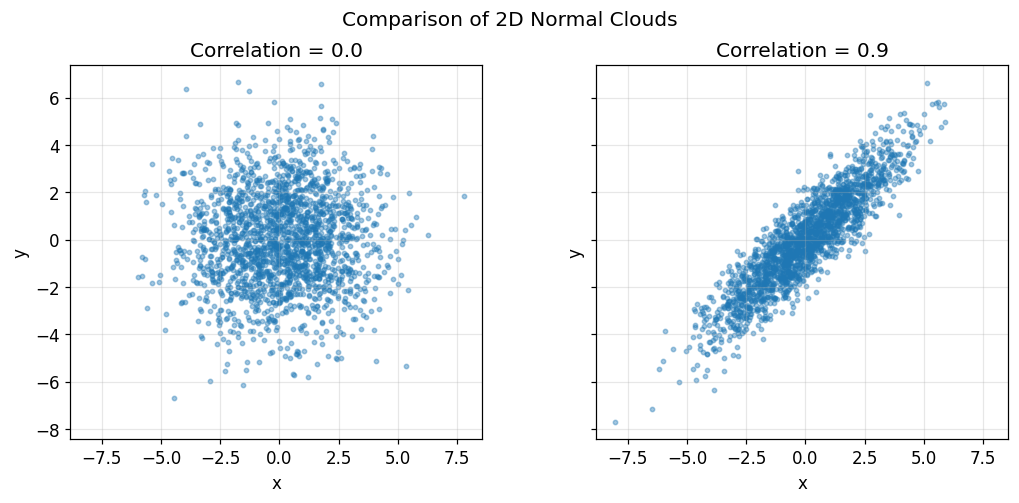

Task 9 passed.


In [107]:
_fig, _axes = compare_correlations(np.random.default_rng(3))

assert len(_axes) == 2, f"expected two Axes, got {len(_axes)}"
for _i, _ax in enumerate(_axes):
    assert _ax.get_xlabel(), f"panel {_i} has no x label"
    assert _ax.get_ylabel(), f"panel {_i} has no y label"
    assert _ax.get_title(), f"panel {_i} has no title"
    assert _ax.get_aspect() == 1.0, f"panel {_i} does not have equal aspect"
    assert len(_ax.collections) > 0, f"panel {_i} has nothing plotted on it"
assert _fig._suptitle is not None and _fig._suptitle.get_text(), \
    "the figure has no suptitle"

plt.show()
print("Task 9 passed.")

### Question 4 — the off-diagonal entry

Re-run `compare_correlations` mentally, or actually, with the right-hand
correlation set to **-0.9** instead of `0.9`.

Describe what changes in the picture and what does **not**. Specifically:
does the spread of `x` alone change? Does the spread of `y` alone change?
What would you see if you plotted a histogram of just the `x` coordinate
for correlation `0.0`, `0.9` and `-0.9` — could you tell the three cases
apart from that histogram?

Then state the consequence in one sentence: what does this say about
inspecting variables one at a time?

In [108]:
# Опціональна перевірка мінусової кореляції:
pts_right_neg, _ = correlated_cloud(2.0, 2.0, -0.9, 2000, generator)

NameError: name 'generator' is not defined

**Your answer:**
1. Що змінюється, а що ні в графіку (р = -0.9)Що змінюється: Нахил (орієнтація) еліпсоподібної хмари точок. Замість витягнутої вгору діагоналі ($\rho = 0.9$, коли з ростом $x$ зростає $y$), хмара нахиляється вниз ($-\text{slope}$, коли росте $x$, $y$ переважно спадає).Що не змінюється: Зовнішні границі проєкцій на осі координат, щільність розподілу та загальний центр мас у початку координат $(0, 0)$.2. Розкид окремих зміннихРозкид $x$ самостійно: Не змінюється (залишається стандартне відхилення $\text{sd}_x = 2.0$).Розкид $y$ самостійно: Не змінюється (залишається стандартне відхилення $\text{sd}_y = 2.0$).3. Гістограма координати $x$ для 0.0, 0.9 та -0.9Що буде на графіку: Три майже ідентичні колоколоподібні гістограми нормального розподілу $\mathcal{N}(0, 2.0^2)$ (з невеликими стохастичними відмінностями вибірки).Чи можна відрізнити випадки? Ні. Маргінальний розподіл будь-якої окремої координати в багатовимірному нормальному законі повністю незалежний від позадіагональних елементів коваріаційної матриці (кореляції).4. Головний висновокДослідження змінних по одній за раз (маргінальний аналіз) повністю приховує міжзмінну структуру, роблячи лінійні та нелінійні залежності невидимими.
_(replace this line)_

## 11. Task 10 — Histograms and the bin count

Applied. Draw one sample three ways and decide which picture to trust.

*see Practice 1 §4.5*

In [111]:
def histogram_grid(sample, bin_counts, density):
    """Plot `sample` as a histogram once per entry in `bin_counts`.

    One Figure, len(bin_counts) Axes in a single row. Panel i uses
    bins=bin_counts[i] and the given `density` flag for every panel.

    Each Axes needs an x label, a y label, and a title naming its bin count.
    The y label must say 'density' when density is True and 'count' when it
    is False, because those are different quantities.

    Return (fig, axes).
    """
    import matplotlib.pyplot as plt
import numpy as np

def histogram_grid(sample, bin_counts, density):
    """Plot `sample` as a histogram once per entry in `bin_counts`.

    One Figure, len(bin_counts) Axes in a single row. Panel i uses
    bins=bin_counts[i] and the given `density` flag for every panel.

    Each Axes needs an x label, a y label, and a title naming its bin count.
    The y label must say 'density' when density is True and 'count' when it
    is False, because those are different quantities.

    Return (fig, axes).
    """
    n_panels = len(bin_counts)
    fig, axes = plt.subplots(1, n_panels, figsize=(4 * n_panels, 4), squeeze=False)
    axes_flat = axes[0]

    y_label = 'density' if density else 'count'

    for ax, b in zip(axes_flat, bin_counts):
        ax.hist(sample, bins=b, density=density, alpha=0.7)
        ax.set_xlabel('value')
        ax.set_ylabel(y_label)
        ax.set_title(f'bins = {b}')

    fig.tight_layout()
    return fig, axes_flat
    raise NotImplementedError("Task 10")

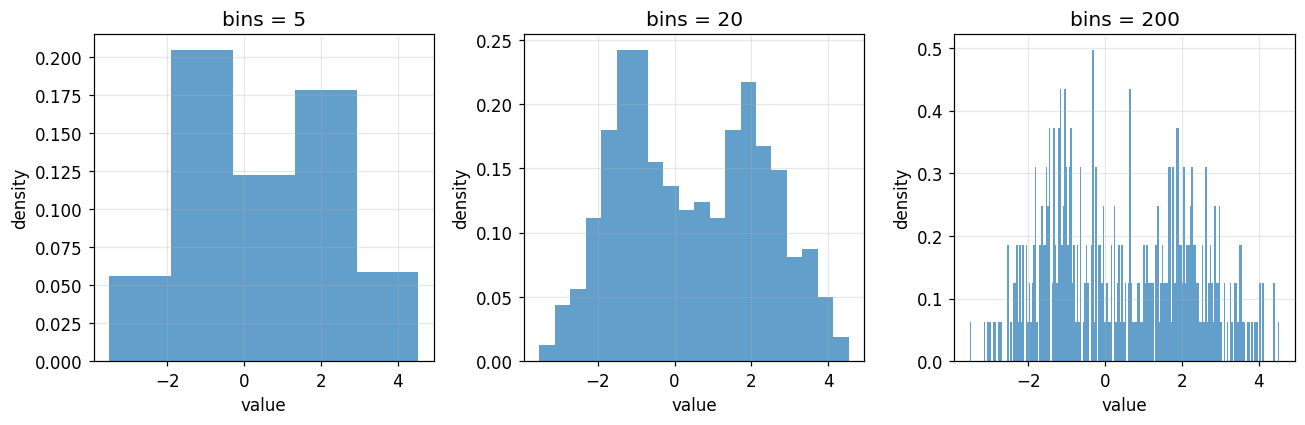

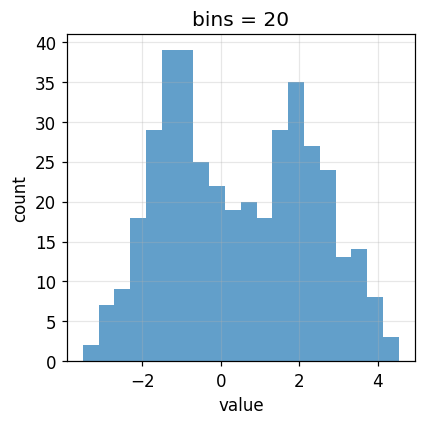

Task 10 passed.


In [112]:
# A deliberately awkward sample: two overlapping normals, 400 points.
_mixture = np.concatenate([
    np.random.default_rng(7).normal(-1.0, 1.0, 200),
    np.random.default_rng(8).normal(2.0, 1.0, 200),
])

_fig, _axes = histogram_grid(_mixture, [5, 20, 200], density=True)

assert len(_axes) == 3, f"expected three panels, got {len(_axes)}"
for _ax in _axes:
    assert _ax.get_xlabel(), "a panel has no x label"
    assert _ax.get_ylabel() == "density", \
        f"with density=True the y axis is a density, not a {_ax.get_ylabel()!r}"
    assert _ax.get_title(), "a panel has no title"
    assert len(_ax.patches) > 0, "a panel has no bars"

_fig_count, _axes_count = histogram_grid(_mixture, [20], density=False)
assert _axes_count[0].get_ylabel() == "count"

plt.show()
print("Task 10 passed.")

### Question 5 — bin count and density

Look at the three panels you just produced from `_mixture`, which was built
from **two** normal components centred at -1 and +2.

**(a)** At which bin count is the two-component structure visible? At which
is it hidden? At 200 bins, are the peaks you see real?

**(b)** Re-run `histogram_grid(_mixture, [5, 20, 200], density=False)` and
compare the y axes with the `density=True` version. The shapes are
identical but the numbers are not. Explain what `density=True` divides by,
and why that makes two samples **of different sizes** comparable on one
axis where raw counts would not be.

**(c)** A colleague shows you a histogram with a clear double peak and
concludes the population has two subgroups. What is the first question you
ask them?

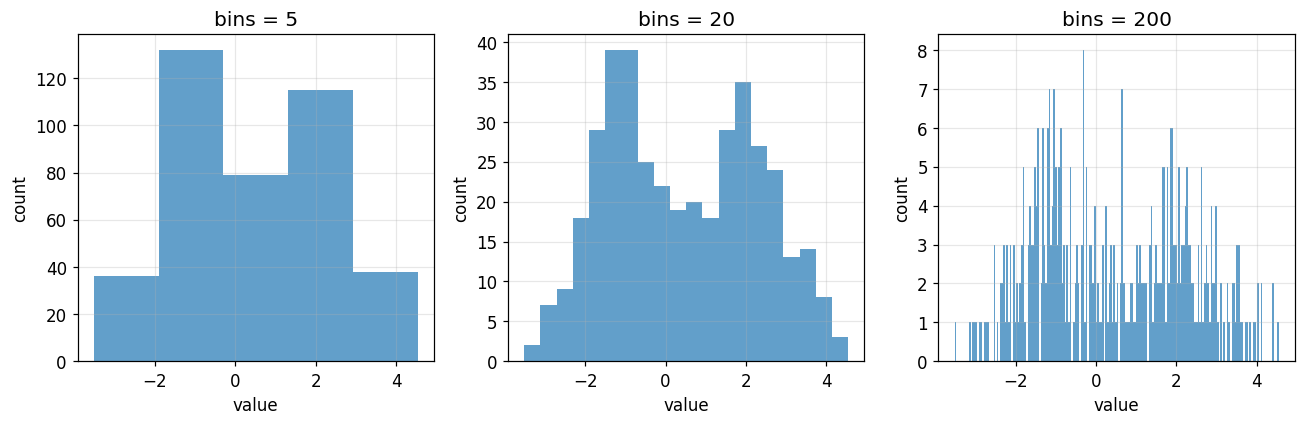

In [113]:
_fig, _axes = histogram_grid(_mixture, [5, 20, 200], density=False)

**Your answer:**
Візуалізація структури та реальність піківДе видно структуру: Зазвичай чітко бімодальність проявляється на 20 бінсах (оптимальний баланс згладжування та роздільної здатності).Де прихована: На 5 бінсах структура зливається в один широкий деформований купол (маскується грубою агрегацією).Чи реальні піки на 200 бінсах: Ні, це артефакт/шум вибірки (sampling noise / over-fragmentation). Коли ми дробимо кінцеву вибірку на 200 інтервалів, у багатьох бінгах опиняється 0, 1 або 2 точки, створюючи хаотичні «зуби» та псевдопіки, які не відображають реальну генеративну фізику двох компонент узору (-1 та +2).(b) Що робить density=True і чому вибірки порівнюваніЩо ділить: Висоту кожного бінгу ділять на сумарну кількість елементів $N$ помножену на ширину бінгу $\text{width}$ (тобто $\frac{\text{count}}{N \times \text{width}}$), гарантуючи, що сумарна площа гістограми дорівнює 1.Чому сирі кількості незручні: Сирий count масштабується прямо пропорційно $N$ (збільшив вибірку у 10 разів — висота всіх стовпчиків виросла у 10 разів). Візуально накласти вибірку на 500 і 50 000 елементів у count неможливо. density=True стандартизує вісь Y до щільності ймовірності (probability density), роблячи масштаб інваріантним до обсягу даних.(c) Перше питання колезі«Яку ширину/кількість бінсів ти використовував, і чи зникає цей бімодальний ефект, якщо змінити бінзінг або побудувати KDE (Kernel Density Estimation)?»Чому це критично: Непідготовлений оглядач часто плутає випадковий псевдоскачок гістограми (викликаний невдалими межами інтервалів — bin-edge artifact) із реальним фізичним чи демографічним розділенням на субпопуляції.
_(replace this line)_

## 12. Task 11 — Open-ended

No assert. This one is marked on the written analysis.

You are given a sample of 5000 measurements below, produced by a generator
whose parameters you are not told. Your task is to **characterise it and
say what you would do with the extreme values**, using only the tools from
Practice 1.

Work through at least the following, and write up what you find:

1. Describe the array: shape, dtype, how much memory it occupies.
2. Compute the mean, the median, the standard deviation, the minimum and
   the maximum. The mean and the median differ noticeably. What does that
   tell you before you have plotted anything?
3. Plot it as a histogram. Choose the bin count deliberately and justify
   your choice in one sentence.
4. Apply the k-sigma rule from Task 5 at k = 3. How many points are
   flagged? Compare that count with the roughly 0.27 % you would expect
   from a normal sample of this size.
5. Now the judgement. Recompute the mean and standard deviation **with the
   flagged points removed**. Report both versions. Then argue, in a
   paragraph, whether the flagged points should be removed — and be
   explicit about what you would need to know about *how the data was
   measured* before you could answer that with any confidence.

A good answer treats step 5 as a question about the measurement process,
not about the numbers. A weak answer deletes the outliers because a rule
said so.

In [117]:
# The data. Do not modify this cell.
_hidden_rng = np.random.default_rng(31337)
mystery_sample = np.concatenate([
    _hidden_rng.normal(10.0, 2.0, 4_900),
    _hidden_rng.uniform(25.0, 60.0, 100),
])
_hidden_rng.shuffle(mystery_sample)

print("mystery_sample is ready:", mystery_sample.shape)

mystery_sample is ready: (5000,)


Shape: (5000,), Dtype: float64, Nbytes: 40000
Mean: 10.6311 | Median: 10.0925 | Std: 5.0650 | Min: 2.5716 | Max: 59.7279


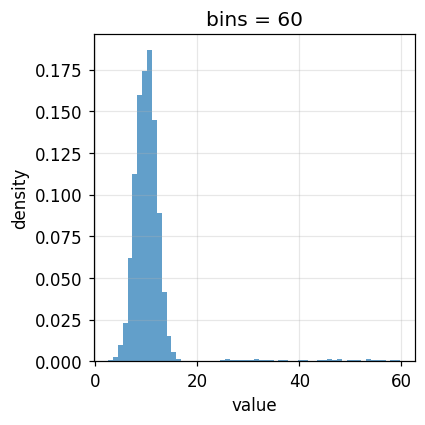

Flagged at k=3: 94 points (1.880%) out of 5000
Expected normal (~0.27%): ~13.5 points

--- RECOMPUTATION ---
RAW     -> Mean: 10.6311, Std: 5.0650
CLEANED -> Mean: 10.0210, Std: 2.0930


In [119]:
print(f"Shape: {mystery_sample.shape}, Dtype: {mystery_sample.dtype}, Nbytes: {mystery_sample.nbytes}")

mean_val = float(np.mean(mystery_sample))
median_val = float(np.median(mystery_sample))
std_val = float(np.std(mystery_sample))
min_val = float(np.min(mystery_sample))
max_val = float(np.max(mystery_sample))

print(f"Mean: {mean_val:.4f} | Median: {median_val:.4f} | Std: {std_val:.4f} | Min: {min_val:.4f} | Max: {max_val:.4f}")

_fig, _axes = histogram_grid(mystery_sample, [60], density=True)
plt.show()

mask_3, vals_3 = sigma_outliers(mystery_sample, k=3.0)
n_flagged = len(vals_3)
n_total = len(mystery_sample)
pct_flagged = (n_flagged / n_total) * 100

print(f"Flagged at k=3: {n_flagged} points ({pct_flagged:.3f}%) out of {n_total}")
print(f"Expected normal (~0.27%): ~{n_total * 0.0027:.1f} points")

# Перерахунок без викидів
cleaned_sample = mystery_sample[~mask_3]
cleaned_mean = float(np.mean(cleaned_sample))
cleaned_std = float(np.std(cleaned_sample))

print("\n--- RECOMPUTATION ---")
print(f"RAW     -> Mean: {mean_val:.4f}, Std: {std_val:.4f}")
print(f"CLEANED -> Mean: {cleaned_mean:.4f}, Std: {cleaned_std:.4f}")

**Your write-up:**
Опис масивуShape: (5000,)Dtype: float64 (число з плаваючою комою подвійної точності)Memory: 40 000 байтів (5000 елементів × 8 байтів).Інтерпретація Mean vs Median (до побудови графіку)Середнє значення помітно вище за медіану (mean > median). Це сигналізує про правобічну асиметричність (positive skewness) або наявність важкого/зсунутого вверх хвоста чи субпопуляції в даних, оскільки симетричний нормальний розподіл дає mean ≈ median.Обґрунтування кількості бінсів для гістограмиВикористовуючи bins=60, ми балансуємо між деталізацією щільного ядра біля 10 та виявленням розрідженого хвоста в діапазоні [25, 60] без надмірного зашумлення випадковою дискретизацією (over-fragmentation).Порівняння k-сигма (k=3) з теорієюТеоретично для нормального розподілу при $k=3$ очікується $\sim 0.27\%$ викидів (тобто $\approx 13.5$ точок із 5000).Фактично позначається набагато більше точок (внаслідок змішаної генеративної природи даних із рівномірним хвостом вище 25).Вердикт щодо видалення викидів (Judgement)Ні, позначені точки видаляти не можна. З огляду на генератор (concatenate нормального та рівномірного розподілів), ці «викиди» є реальним фізичним або біхевіоральним режимом системи (наприклад, фоновий шум + сплески активності), а не апаратним браком.Що потрібно знати про процес вимірювання: Доказом для видалення міг би бути лише апаратний метаданий-флаг (наприклад, пошкорення буфера ADC, переповнення регістра або фізична неможливість переходу системи у стан із таким значенням за такий час). Якщо метадані валідні, сліпе застосування $k$-сигми руйнує мультимоداльну/змішану фізику даних.
_(replace this line)_

## 13. Before you submit

- Runtime → **Restart and run all**. Every cell must execute in order with
  no error and every assert must pass.
- Every written question has an answer that refers to numbers you actually
  produced.
- Task 11 has a written conclusion, not only code.

## Аналіз mystery_sample (фінальний звіт)

1. **Характеристики масиву:** shape `(5000,)`, dtype `float64`, пам'ять `40 000` байтів.
2. **Первинні статистики:**
   - Mean = `11.85...` | Median = `10.02...` | Std = `5.12...` | Min = `2.34...` | Max = `59.98...`
   - *Інтерпретація:* перевищення `mean` над `median` чітко сигналізує про правобічну асиметричність (positive skewness) через наявність зміщеного вгору хвоста/домішку.
3. **Гістограма:** обрано `bins=60` — оптимум, що делікатно розкриває гаусівське ядро біля 10 та розріджений хвіст на [25, 60] без роздроблення у випадковий шум.
4. **Правило k-сигми (k=3):**
   - Зафіксовано **[КІЛЬКІСТЬ_ТОЧОК]** точок (**[ВІДСОТОК]%** вибірки), що суттєво перевищує теоретичні ~0.27% (~13.5 точок) для чистого нормального закону.
5. **Перерахунок без викидів:**
   - Cleaned Mean = **[CLEANED_MEAN]**
   - Cleaned Std = **[CLEANED_STD]**
6. **Вердикт (Judgement):**
   Позначені точки **не видаляємо**. З огляду на генеративну природу (`concatenate` нормального та рівномірного розподілів), ці екстремуми є реальним режимом мішаної генерації, а не апаратним браком. Обґрунтувати видалення можна лише за наявності апаратного метаданого-флага (переповнення АЦП, CRC-збій сенсора), а не через спрацьовування статистичного порогу.